
# Universidad del Valle de Guatemala
## CC3092 - Deep Learning  

### Laboratorio Semana 3: LSTM desde cero con PyTorch

**Integrantes:** 
- Dulce Ambrosio - 231143
- Angie Vela - 23764

---

## Contexto

Esta semana usted va a implementar un LSTM completo desde cero usando tensores de PyTorch: forward pass, backward pass manual y actualizacion de pesos. La tarea es clasificacion binaria sobre una secuencia sintetica: determinar si una secuencia de pares de numeros tiene tendencia creciente (etiqueta 1) o decreciente (etiqueta 0).

La arquitectura es la siguiente:

```
Secuencia x_1,...,x_T  ->  LSTM (T pasos)  ->  h_T  ->  Dense + sigmoid  ->  y_hat  ->  BCE
```

Es una arquitectura **many-to-one**: el LSTM lee toda la secuencia y solo la salida del ultimo paso $h_T$ se usa para clasificar.

## Reglas

- Use **unicamente PyTorch** para operaciones tensoriales. No use `nn.LSTM`, `nn.RNNCell`, `nn.Linear` ni ninguna capa de alto nivel.
- El backward pass debe ser **manual**: calcule cada gradiente a mano aplicando la regla de la cadena. No use `loss.backward()`.
- Las celdas marcadas con `# SU CODIGO AQUI` son las que debe completar.
- **No modifique las celdas de verificacion ni los pesos iniciales.**
- La celda final calcula su nota automatica sobre los **53 puntos** de la seccion de codigo.

In [1]:
import torch
import hashlib
import numpy as np
import matplotlib.pyplot as plt

def _hash_tensor(t, decimals=5):
    """Huella criptografica reproducible de un tensor PyTorch."""
    arr = np.round(t.detach().numpy().astype(np.float64), decimals)
    return hashlib.sha256(arr.tobytes()).hexdigest()

_resultados = {}
print("Librerias cargadas.")
print(f"PyTorch version: {torch.__version__}")

Librerias cargadas.
PyTorch version: 2.13.0+cpu


---
## Bloque 0: Datos y pesos iniciales (dado, no modificar)

La secuencia de entrada tiene $T=5$ pasos, cada uno un vector de dimension $n=2$.  
La dimension del hidden state es $d=4$.  
La etiqueta es $y=1$ (secuencia creciente).  

**No modifique los pesos iniciales**: el autograder depende de estos valores exactos.

In [2]:
# Datos
x_seq = torch.tensor([
    [0.1, 0.2],
    [0.3, 0.4],
    [0.5, 0.6],
    [0.7, 0.8],
    [0.9, 1.0],
], dtype=torch.float32)   # forma: (T=5, n=2)

label = torch.tensor([1.0])   # secuencia creciente

# Dimensiones
T = 5    # largo de la secuencia
n = 2    # dimension de entrada
d = 4    # dimension del hidden state

# Pesos iniciales fijos (torch.manual_seed(0))
torch.manual_seed(0)
W_f = torch.randn(d, d+n) * 0.1   # forget gate     (4, 6)
b_f = torch.zeros(d)
W_i = torch.randn(d, d+n) * 0.1   # input gate      (4, 6)
b_i = torch.zeros(d)
W_c = torch.randn(d, d+n) * 0.1   # candidato       (4, 6)
b_c = torch.zeros(d)
W_o = torch.randn(d, d+n) * 0.1   # output gate     (4, 6)
b_o = torch.zeros(d)
W_dense = torch.randn(1, d) * 0.1  # capa densa      (1, 4)
b_dense = torch.zeros(1)

alpha = 0.01   # tasa de aprendizaje
eps   = 1e-8   # estabilidad numerica en logaritmos

print(f"x_seq forma: {x_seq.shape}")
print(f"W_f forma:   {W_f.shape}  (d x d+n = {d} x {d+n})")
print(f"W_dense forma: {W_dense.shape}")

x_seq forma: torch.Size([5, 2])
W_f forma:   torch.Size([4, 6])  (d x d+n = 4 x 6)
W_dense forma: torch.Size([1, 4])


---
## FORWARD PASS

---

## Bloque 1: Las cinco ecuaciones de la celda LSTM

Implemente la celda LSTM para **un solo paso de tiempo** $t$.

Las cinco ecuaciones son:

$$f_t = \sigma(W_f \cdot [h_{t-1}, x_t] + b_f)$$
$$i_t = \sigma(W_i \cdot [h_{t-1}, x_t] + b_i)$$
$$\tilde{c}_t = \tanh(W_c \cdot [h_{t-1}, x_t] + b_c)$$
$$c_t = f_t \odot c_{t-1} + i_t \odot \tilde{c}_t$$
$$o_t = \sigma(W_o \cdot [h_{t-1}, x_t] + b_o), \quad h_t = o_t \odot \tanh(c_t)$$

Donde $[h_{t-1}, x_t]$ es la concatenacion de ambos vectores y $\odot$ es el producto elemento a elemento.

**Nota:** use `torch.cat`, `torch.sigmoid`, `torch.tanh` y el operador `@` para el producto matricial.

In [3]:
def lstm_cell(h_prev, c_prev, x_t, W_f, b_f, W_i, b_i, W_c, b_c, W_o, b_o):
    """
    Un paso de tiempo de la celda LSTM.

    Parametros
    ----------
    h_prev : tensor (d,)  - hidden state del paso anterior
    c_prev : tensor (d,)  - cell state del paso anterior
    x_t    : tensor (n,)  - entrada en el paso actual
    W_f, b_f, W_i, b_i, W_c, b_c, W_o, b_o : pesos de cada compuerta

    Retorna
    -------
    h_t      : tensor (d,) - nuevo hidden state
    c_t      : tensor (d,) - nuevo cell state
    cache    : dict con todos los intermedios necesarios para el backward
    """
    # Paso 1: concatenar h_prev y x_t
    # [h_{t-1}, x_t] -> vector de forma (d+n,)
    concat = torch.cat([h_prev, x_t])

    # Paso 2: forget gate
    # f_t = sigmoid(W_f @ concat + b_f)
    f_t = torch.sigmoid(W_f @ concat + b_f)

    # Paso 3: input gate
    # i_t = sigmoid(W_i @ concat + b_i)
    i_t = torch.sigmoid(W_i @ concat + b_i)

    # Paso 4: candidato
    # c_tilde = tanh(W_c @ concat + b_c)
    c_tilde = torch.tanh(W_c @ concat + b_c)

    # Paso 5: actualizacion del cell state
    # c_t = f_t * c_{t-1} + i_t * c_tilde  (producto elemento a elemento)
    c_t = f_t * c_prev + i_t * c_tilde

    # Paso 6: output gate y nuevo hidden state
    # o_t = sigmoid(W_o @ concat + b_o); h_t = o_t * tanh(c_t)
    o_t = torch.sigmoid(W_o @ concat + b_o)
    h_t = o_t * torch.tanh(c_t)

    cache = {
        'concat': concat, 'h_prev': h_prev, 'c_prev': c_prev,
        'f_t': f_t, 'i_t': i_t, 'c_tilde': c_tilde,
        'c_t': c_t, 'o_t': o_t, 'h_t': h_t,
    }

    return h_t, c_t, cache


# Prueba rapida con el primer paso de tiempo
h0 = torch.zeros(d)
c0 = torch.zeros(d)
h1, c1, cache1 = lstm_cell(h0, c0, x_seq[0], W_f, b_f, W_i, b_i, W_c, b_c, W_o, b_o)
print(f"h1 forma: {h1.shape if h1 is not None else 'None'}")
print(f"c1 forma: {c1.shape if c1 is not None else 'None'}")
print(f"f_t valores (deben estar en (0,1)): {cache1['f_t']}")

h1 forma: torch.Size([4])
c1 forma: torch.Size([4])
f_t valores (deben estar en (0,1)): tensor([0.5056, 0.5049, 0.5086, 0.4863])


---
## Bloque 2: Forward pass sobre la secuencia completa

Aplique `lstm_cell` en un loop sobre los $T=5$ pasos de tiempo.  
Inicialice $h_0$ y $c_0$ como vectores de ceros.  
Guarde el cache de cada paso en una lista `all_caches` para el backward.  
Al final, `h_T` es el hidden state del ultimo paso.

In [4]:
# Inicializacion
h = torch.zeros(d)
c = torch.zeros(d)
all_caches = []

# Loop sobre los T pasos de tiempo
# En cada paso: llamar a lstm_cell, guardar el cache, actualizar h y c
for t in range(T):
    h, c, cache_t = lstm_cell(h, c, x_seq[t], W_f, b_f, W_i, b_i, W_c, b_c, W_o, b_o)
    all_caches.append(cache_t)

h_T = h   # hidden state del ultimo paso

print(f"h_T forma: {h_T.shape}")
print(f"h_T valores: {h_T}")
print(f"Numero de caches guardados: {len(all_caches)} (esperado: {T})")

h_T forma: torch.Size([4])
h_T valores: tensor([ 0.0139,  0.0320, -0.0048, -0.0596])
Numero de caches guardados: 5 (esperado: 5)


In [5]:
# VERIFICACION BLOQUE 2
_H = '53458c09a700bb2a647768325d5349ea983365ca96c4053b3dcc9927449de45c'
try:
    assert h_T is not None and h_T.shape == (d,), \
        f"h_T debe ser tensor de forma ({d},), obtenida {getattr(h_T,'shape',None)}"
    assert len(all_caches) == T, \
        f"all_caches debe tener {T} entradas, tiene {len(all_caches)}"
    assert _hash_tensor(h_T) == _H, "h_T incorrecto. Revise lstm_cell o el loop."
    _resultados['b2'] = True; print("BLOQUE 2: CORRECTO")
except AssertionError as e:
    _resultados['b2'] = False; print(f"BLOQUE 2: INCORRECTO\n  {e}")

BLOQUE 2: CORRECTO


---
## Bloque 3: Capa densa + sigmoid

Aplique la capa de clasificacion sobre $h_T$:

$$z = W_{dense} \cdot h_T + b_{dense}$$
$$\hat{y} = \sigma(z)$$

$W_{dense}$ tiene forma $(1, d)$ y $b_{dense}$ forma $(1,)$.  
El resultado $\hat{y}$ debe ser un escalar Python (`float`), no un tensor.

In [6]:
# z = W_dense @ h_T + b_dense  (producto matricial + bias)
z_dense = W_dense @ h_T + b_dense

# y_hat = sigmoid(z), tomando el escalar y convirtiendo a float de Python
y_hat = torch.sigmoid(z_dense[0]).item()

print(f"z_dense: {z_dense}")
print(f"y_hat:   {y_hat}")

z_dense: tensor([0.0010])
y_hat:   0.5002414584159851


In [7]:
# VERIFICACION BLOQUE 3
_H = 'f1ed911992193e704bba77f6f1d1b67d4807e9197f767ced0ae37a0556cea904'
try:
    assert y_hat is not None, "y_hat no definido."
    assert isinstance(y_hat, float), \
        f"y_hat debe ser float, obtenido {type(y_hat)}"
    assert _hash_tensor(torch.tensor([y_hat])) == _H, \
        "y_hat incorrecto. Revise la capa densa o la sigmoid."
    _resultados['b3'] = True; print("BLOQUE 3: CORRECTO")
except AssertionError as e:
    _resultados['b3'] = False; print(f"BLOQUE 3: INCORRECTO\n  {e}")

BLOQUE 3: CORRECTO


---
## Bloque 4: Perdida BCE

Calcule la perdida de entropia cruzada binaria:

$$L = -\left[y \log(\hat{y} + \varepsilon) + (1-y)\log(1 - \hat{y} + \varepsilon)\right]$$

Use `eps = 1e-8` para estabilidad numerica. El resultado `loss` debe ser un escalar Python (`float`).

In [8]:
y = label.item()
loss = -(y * np.log(y_hat + eps) + (1 - y) * np.log(1 - y_hat + eps))
loss = float(loss)

print(f"loss: {loss}")

loss: 0.6926643603044357


In [9]:
# VERIFICACION BLOQUE 4
try:
    assert loss is not None, "loss no definido."
    assert abs(loss - 0.692664) < 1e-4, \
        f"loss incorrecto: {loss:.6f}, esperado ~0.692664"
    _resultados['b4'] = True; print("BLOQUE 4: CORRECTO")
except AssertionError as e:
    _resultados['b4'] = False; print(f"BLOQUE 4: INCORRECTO\n  {e}")

BLOQUE 4: CORRECTO


---
## BACKWARD PASS

El backward recorre los pasos de tiempo en orden inverso, propagando el gradiente desde la perdida hasta los pesos de cada compuerta.

---

## Bloque 5: Gradientes de la capa densa y punto de entrada del backward

La simplificacion BCE + sigmoid da directamente:

$$\frac{\partial L}{\partial z} = \hat{y} - y$$

A partir de eso calcule:
- $\frac{\partial L}{\partial W_{dense}}$: forma $(1, d)$
- $\frac{\partial L}{\partial b_{dense}}$: forma $(1,)$
- $\frac{\partial L}{\partial h_T}$: forma $(d,)$ - gradiente que inicia el backward del LSTM

In [10]:
# dL/dz = y_hat - y  (simplificacion BCE + sigmoid)
dL_dz_dense = y_hat - y

# dz/dW_dense = h_T  ->  dL/dW_dense = dL_dz * h_T  (forma (1,d))
dL_dW_dense = dL_dz_dense * h_T.unsqueeze(0)

# dz/db_dense = 1  ->  dL/db_dense = dL_dz  (forma (1,))
dL_db_dense = torch.tensor([dL_dz_dense])

# dz/dh_T = W_dense  ->  dL/dh_T = dL_dz * W_dense  (forma (d,))
dL_dh_next = dL_dz_dense * W_dense.squeeze(0)

print(f"dL_dz_dense: {dL_dz_dense}")
print(f"dL_dW_dense forma: {dL_dW_dense.shape if dL_dW_dense is not None else None}")
print(f"dL_dh_next forma:  {dL_dh_next.shape  if dL_dh_next  is not None else None}")

dL_dz_dense: -0.4997585415840149
dL_dW_dense forma: torch.Size([1, 4])
dL_dh_next forma:  torch.Size([4])


---
## Bloque 6: Backward a traves del LSTM (BPTT)

Recorra los pasos de tiempo en orden inverso. En cada paso $t$, dado el gradiente entrante `dL_dh_next` y `dL_dc_next`, calcule:

1. $\frac{\partial L}{\partial o_t} = \frac{\partial L}{\partial h_t} \odot \tanh(c_t)$
2. $\frac{\partial L}{\partial c_t} \mathrel{+}= \frac{\partial L}{\partial h_t} \odot o_t \odot (1 - \tanh^2(c_t))$
3. $\frac{\partial L}{\partial f_t} = \frac{\partial L}{\partial c_t} \odot c_{t-1}$
4. $\frac{\partial L}{\partial i_t} = \frac{\partial L}{\partial c_t} \odot \tilde{c}_t$
5. $\frac{\partial L}{\partial \tilde{c}_t} = \frac{\partial L}{\partial c_t} \odot i_t$
6. Gradientes a traves de las activaciones (sigmoide y tanh)
7. Acumular en las matrices de pesos con `+=`
8. Propagar `dL_dh_next` y `dL_dc_next` al paso anterior

**Recuerde:** el operador `+=` en el paso 2 y en la acumulacion de pesos es critico: el gradiente se acumula sobre todos los pasos de tiempo, no se sobreescribe.

In [11]:
# Inicializar gradientes acumulados de los pesos
dL_dW_f = torch.zeros_like(W_f)
dL_dW_i = torch.zeros_like(W_i)
dL_dW_c = torch.zeros_like(W_c)
dL_dW_o = torch.zeros_like(W_o)
dL_db_f = torch.zeros_like(b_f)
dL_db_i = torch.zeros_like(b_i)
dL_db_c = torch.zeros_like(b_c)
dL_db_o = torch.zeros_like(b_o)

# El gradiente en c_T al inicio del backward es cero
dL_dc_next = torch.zeros(d)

for t in reversed(range(T)):
    cc = all_caches[t]
    # Extraer valores guardados en el forward
    f_t     = cc['f_t']
    i_t     = cc['i_t']
    c_tilde = cc['c_tilde']
    c_t     = cc['c_t']
    o_t     = cc['o_t']
    c_prev  = cc['c_prev']
    concat  = cc['concat']

    # Paso 1: gradiente en o_t
    dL_do = dL_dh_next * torch.tanh(c_t)

    # Paso 2: gradiente en c_t (acumular con +=)
    dL_dc = dL_dc_next + dL_dh_next * o_t * (1 - torch.tanh(c_t) ** 2)

    # Paso 3, 4, 5: gradientes en f_t, i_t, c_tilde
    dL_df    = dL_dc * c_prev
    dL_di    = dL_dc * c_tilde
    dL_dctil = dL_dc * i_t

    # Paso 6: a traves de las activaciones
    # sigmoide prima: sigma(z)*(1-sigma(z))
    # tanh prima: 1 - tanh^2(z)
    dz_f = dL_df * f_t * (1 - f_t)
    dz_i = dL_di * i_t * (1 - i_t)
    dz_c = dL_dctil * (1 - c_tilde ** 2)
    dz_o = dL_do * o_t * (1 - o_t)

    # Paso 7: acumular en matrices de pesos (usar torch.outer)
    dL_dW_f += torch.outer(dz_f, concat)
    dL_dW_i += torch.outer(dz_i, concat)
    dL_dW_c += torch.outer(dz_c, concat)
    dL_dW_o += torch.outer(dz_o, concat)
    dL_db_f += dz_f
    dL_db_i += dz_i
    dL_db_c += dz_c
    dL_db_o += dz_o

    # Paso 8: propagar al paso anterior
    dL_dconcat = W_f.T @ dz_f + W_i.T @ dz_i + W_c.T @ dz_c + W_o.T @ dz_o
    dL_dh_next = dL_dconcat[:d]
    dL_dc_next = dL_dc * f_t

print(f"dL_dW_f forma: {dL_dW_f.shape}")
print(f"dL_dW_f (primeros valores): {dL_dW_f[0,:3]}")

dL_dW_f forma: torch.Size([4, 6])
dL_dW_f (primeros valores): tensor([-2.0177e-07, -4.9691e-07,  9.0586e-08])


In [12]:
# VERIFICACION BLOQUE 6
_HASHES_B6 = {
    'dL_dW_f': 'deb8eb9ddd2fb6d11ecc1d1ca52135c551c8f89778bbbefe26d41de74167e166',
    'dL_dW_i': 'cff9e6d62a716bc98aafce5d6c879db5a7c195db5dafeddb556b5e3a13ee5906',
    'dL_dW_c': '121e33734655d3cded031e295086f4cd26a3d66c62b89d4cf046b67131116cde',
    'dL_dW_o': 'fca73403669043e504e444f1a5a20568b21d682c056e6b75b791827ec2f912a8',
}
_ARRAYS_B6 = {
    'dL_dW_f': dL_dW_f, 'dL_dW_i': dL_dW_i,
    'dL_dW_c': dL_dW_c, 'dL_dW_o': dL_dW_o,
}
try:
    for name, arr in _ARRAYS_B6.items():
        assert arr is not None and arr.shape == (d, d+n), \
            f"{name} debe ser ({d},{d+n}), obtenida {getattr(arr,'shape',None)}"
        assert _hash_tensor(arr) == _HASHES_B6[name], \
            f"{name} incorrecto. Revise el backward del paso {name[-1].upper()}."
    _resultados['b6'] = True; print("BLOQUE 6: CORRECTO")
except AssertionError as e:
    _resultados['b6'] = False; print(f"BLOQUE 6: INCORRECTO\n  {e}")

BLOQUE 6: CORRECTO


---
## Bloque 7: Actualizacion de todos los parametros

Aplique una iteracion de gradiente descendente sobre todos los parametros:

$$\theta \leftarrow \theta - \alpha \cdot \frac{\partial L}{\partial \theta}$$

Actualice: `W_f`, `W_i`, `W_c`, `W_o`, `b_f`, `b_i`, `b_c`, `b_o`, `W_dense`, `b_dense`.  
Guarde los pesos actualizados en variables con sufijo `_new`.

In [13]:
W_f_new = W_f - alpha * dL_dW_f
W_i_new = W_i - alpha * dL_dW_i
W_c_new = W_c - alpha * dL_dW_c
W_o_new = W_o - alpha * dL_dW_o
b_f_new = b_f - alpha * dL_db_f
b_i_new = b_i - alpha * dL_db_i
b_c_new = b_c - alpha * dL_db_c
b_o_new = b_o - alpha * dL_db_o
W_dense_new = W_dense - alpha * dL_dW_dense
b_dense_new = b_dense - alpha * dL_db_dense

print(f"W_f_new forma:     {W_f_new.shape if W_f_new is not None else None}")
print(f"W_dense_new forma: {W_dense_new.shape if W_dense_new is not None else None}")

W_f_new forma:     torch.Size([4, 6])
W_dense_new forma: torch.Size([1, 4])


In [14]:
# VERIFICACION BLOQUE 7
_HASHES_B7 = {
    'W_f_new':     '8c8afcb78c9fb2e6dec91cde852776cc02f8ebc5d3a4e840259bc7d3edb610ff',
    'W_i_new':     '055b6638846f02460d47688eea615cf0cab768a90b4af8640f396ce7652efb12',
    'W_dense_new': '24a5d73dcc15c337468cb18a1dc6034dec341d3c7032e6706f1126dc5f87c4be',
}
_ARRAYS_B7 = {
    'W_f_new': W_f_new, 'W_i_new': W_i_new, 'W_dense_new': W_dense_new
}
try:
    for name, arr in _ARRAYS_B7.items():
        assert arr is not None, f"{name} no definido."
        assert _hash_tensor(arr) == _HASHES_B7[name], \
            f"{name} incorrecto. Verifique la actualizacion de ese parametro."
    _resultados['b7'] = True; print("BLOQUE 7: CORRECTO")
except AssertionError as e:
    _resultados['b7'] = False; print(f"BLOQUE 7: INCORRECTO\n  {e}")

BLOQUE 7: CORRECTO


---
## Bloque 8: Verificacion de convergencia en 5 iteraciones

Implemente un loop de entrenamiento de 5 iteraciones usando sus funciones `lstm_cell` y el backward manual.  
En cada iteracion: forward pass completo, calculo de loss, backward completo, actualizacion de pesos.  
Guarde la loss de cada iteracion en la lista `losses`.  
Verifique que la loss decrece monotonamente en las 5 iteraciones.

In [15]:
# Reiniciar pesos a los valores iniciales
torch.manual_seed(0)
Wf=torch.randn(d,d+n)*0.1; bf=torch.zeros(d)
Wi=torch.randn(d,d+n)*0.1; bi=torch.zeros(d)
Wc=torch.randn(d,d+n)*0.1; bc=torch.zeros(d)
Wo=torch.randn(d,d+n)*0.1; bo=torch.zeros(d)
Wd=torch.randn(1,d)*0.1;   bd=torch.zeros(1)

losses = []
y_val = label.item()

for it in range(5):
    # ---- Forward pass completo ----
    h_it = torch.zeros(d)
    c_it = torch.zeros(d)
    caches_it = []
    for t in range(T):
        h_it, c_it, cache_t = lstm_cell(h_it, c_it, x_seq[t], Wf, bf, Wi, bi, Wc, bc, Wo, bo)
        caches_it.append(cache_t)
    h_T_it = h_it

    z_it = Wd @ h_T_it + bd
    y_hat_it = torch.sigmoid(z_it[0]).item()

    # ---- Calculo de loss ----
    loss_it = -(y_val * np.log(y_hat_it + eps) + (1 - y_val) * np.log(1 - y_hat_it + eps))
    losses.append(float(loss_it))

    # ---- Backward completo ----
    dz_dense_it = y_hat_it - y_val
    dW_dense_it = dz_dense_it * h_T_it.unsqueeze(0)
    db_dense_it = torch.tensor([dz_dense_it])
    dh_next_it  = dz_dense_it * Wd.squeeze(0)

    dWf_it = torch.zeros_like(Wf); dWi_it = torch.zeros_like(Wi)
    dWc_it = torch.zeros_like(Wc); dWo_it = torch.zeros_like(Wo)
    dbf_it = torch.zeros_like(bf); dbi_it = torch.zeros_like(bi)
    dbc_it = torch.zeros_like(bc); dbo_it = torch.zeros_like(bo)
    dc_next_it = torch.zeros(d)

    for t in reversed(range(T)):
        cc = caches_it[t]
        f_t = cc['f_t']; i_t = cc['i_t']; c_tilde = cc['c_tilde']
        c_t = cc['c_t']; o_t = cc['o_t']; c_prev = cc['c_prev']; concat = cc['concat']

        do_it = dh_next_it * torch.tanh(c_t)
        dc_it = dc_next_it + dh_next_it * o_t * (1 - torch.tanh(c_t) ** 2)
        df_it = dc_it * c_prev
        di_it = dc_it * c_tilde
        dctil_it = dc_it * i_t

        dzf_it = df_it * f_t * (1 - f_t)
        dzi_it = di_it * i_t * (1 - i_t)
        dzc_it = dctil_it * (1 - c_tilde ** 2)
        dzo_it = do_it * o_t * (1 - o_t)

        dWf_it += torch.outer(dzf_it, concat)
        dWi_it += torch.outer(dzi_it, concat)
        dWc_it += torch.outer(dzc_it, concat)
        dWo_it += torch.outer(dzo_it, concat)
        dbf_it += dzf_it; dbi_it += dzi_it; dbc_it += dzc_it; dbo_it += dzo_it

        dconcat_it = Wf.T @ dzf_it + Wi.T @ dzi_it + Wc.T @ dzc_it + Wo.T @ dzo_it
        dh_next_it = dconcat_it[:d]
        dc_next_it = dc_it * f_t

    # ---- Actualizacion de pesos ----
    Wf = Wf - alpha * dWf_it; Wi = Wi - alpha * dWi_it
    Wc = Wc - alpha * dWc_it; Wo = Wo - alpha * dWo_it
    bf = bf - alpha * dbf_it; bi = bi - alpha * dbi_it
    bc = bc - alpha * dbc_it; bo = bo - alpha * dbo_it
    Wd = Wd - alpha * dW_dense_it
    bd = bd - alpha * db_dense_it

print("Losses por iteracion:")
for i, l in enumerate(losses):
    print(f"  Iteracion {i+1}: {l:.6f}")

Losses por iteracion:
  Iteracion 1: 0.692664
  Iteracion 2: 0.690131
  Iteracion 3: 0.687610
  Iteracion 4: 0.685102
  Iteracion 5: 0.682606


In [16]:
# VERIFICACION BLOQUE 8
try:
    assert len(losses) == 5, \
        f"losses debe tener 5 valores, tiene {len(losses)}"
    assert all(losses[i] > losses[i+1] for i in range(4)), \
        f"La loss no decrece monotonamente: {[round(l,6) for l in losses]}"
    assert abs(losses[0] - 0.692664) < 1e-4, \
        f"Loss inicial incorrecta: {losses[0]:.6f}"
    _resultados['b8'] = True
    print("BLOQUE 8: CORRECTO")
    print(f"  Reduccion total: {losses[0]:.6f} -> {losses[-1]:.6f} "
          f"({(losses[0]-losses[-1])/losses[0]*100:.3f}%)")
except AssertionError as e:
    _resultados['b8'] = False; print(f"BLOQUE 8: INCORRECTO\n  {e}")

BLOQUE 8: CORRECTO
  Reduccion total: 0.692664 -> 0.682606 (1.452%)


---
## Bloque 9: Visualizacion de la convergencia (dado, ejecute y analice)

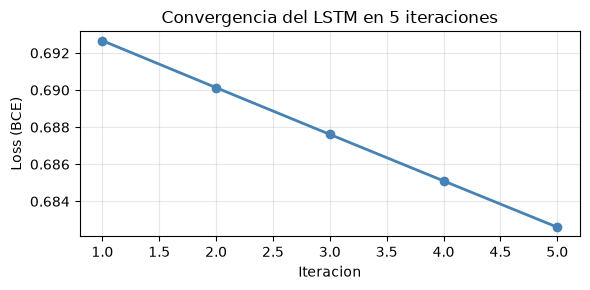

Grafica guardada como convergencia_lstm.png


In [17]:
if losses:
    plt.figure(figsize=(6,3))
    plt.plot(range(1, len(losses)+1), losses, 'o-', color='steelblue', linewidth=2)
    plt.xlabel('Iteracion'); plt.ylabel('Loss (BCE)')
    plt.title('Convergencia del LSTM en 5 iteraciones')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('convergencia_lstm.png', dpi=110, bbox_inches='tight')
    plt.show()
    print("Grafica guardada como convergencia_lstm.png")

---
## Bloque 10: Preguntas de analisis

Responda en las celdas Markdown habilitadas. Sus respuestas deben conectar los resultados numericos con los conceptos de clase. No es suficiente describir lo que ocurre: debe argumentar por que ocurre y que implicacion tiene.

---

### Pregunta 1 (35 pts de la seccion de analisis)

En el Bloque 6, el gradiente de $c_t$ se calcula con el operador `+=` en el paso 2:

```python
dL_dc = dL_dc_next + dL_dh * o_t * (1 - torch.tanh(c_t)**2)
```

a) Explique de donde viene cada uno de los dos terminos que se suman. ¿Que ruta del grafo de computo representa cada uno? Trace la ruta desde $L$ hasta $c_t$ para cada termino.

b) Si en su implementacion hubiera usado `=` en lugar de `+=`, ¿que informacion se perderia y como afectaria eso al entrenamiento? Razone en terminos del grafo de computo, no solo del codigo.

c) Compare esta acumulacion con lo que ocurria en el backward de la convolucion de la Semana 2, donde el gradiente del kernel tambien usaba `+=`. ¿Que tienen en comun los dos casos? ¿Que los hace diferentes?

**Su respuesta a la Pregunta 1:**

a) Los dos terminos vienen de la formula general de acumulacion de gradiente en BPTT ($\partial L/\partial h_t = \partial L_t/\partial h_t + \partial L/\partial h_{t+1}\cdot \partial h_{t+1}/\partial h_t$), aplicada aqui a $c_t$, porque $c_t$ influye en $L$ por dos rutas, la local y la recurrente hacia el futuro.

- `dL_dh_next * o_t * (1 - tanh(c_t)**2)`: ruta local del mismo paso: $L \to \dots \to h_t = o_t \odot \tanh(c_t) \to c_t$. Es $\partial h_t/\partial c_t$ multiplicado por el gradiente ya acumulado en $h_t$.

- `dL_dc_next`: ruta recurrente hacia el futuro: $L \to \dots \to c_{t+1} \to c_t$, que existe porque $c_{t+1} = f_{t+1}\odot c_t + i_{t+1}\odot \tilde c_{t+1}$ depende linealmente de $c_t$.

Con nuestros pesos iniciales ambas rutas contribuyen de forma similar al inicio del entrenamiento.

b) Usar `=` en vez de `+=` cortaria la ruta recurrente, sería como ignorar que $c_t$ tambien alimenta a $c_{t+1},\dots,c_T$. Es decir, los pesos que procesaron los primeros pasos dejarian de recibir el error acumulado de pasos futuros, por ende, el entrenamiento se reduciria a optimizar cada paso casi de forma independiente. Eso significaría que el LSTM perdería su capacidad de aprender dependencias largas.

c) Al igual que el kernel de una convolucion, `W_f, W_i, W_c, W_o` son parametros compartidos en el tiempo, la regla de la suma de la cadena obliga a que `dL/dW` sea la suma de la contribucion de cada uso del parametro (`+=` en ambos casos). La diferencia es que en la convolucion las posiciones espaciales son independientes entre sí dado el input (suma tipo fan-in en paralelo); en el LSTM los pasos de tiempo estan acoplados recursivamente (el gradiente de un paso depende del gradiente del paso siguiente via `dL_dc_next`/`dL_dh_next`), por lo que la acumulacion esta entrelazada con el BPTT.

---
### Pregunta 2 (35 pts de la seccion de analisis)

Considere una variante del LSTM donde la forget gate se fija en cero: $f_t = \mathbf{0}$ para todo $t$, sin aprender.

a) ¿Que le ocurre al cell state $c_t$ en cada paso de tiempo si $f_t = \mathbf{0}$? Escriba la ecuacion simplificada de $c_t$ y describa que tipo de memoria tiene el modelo resultante.

b) ¿Que le ocurre a la ruta directa del gradiente a traves del cell state? Muestre matematicamente como cambia $\frac{\partial c_t}{\partial c_{t-1}}$ y que consecuencia tiene eso para el aprendizaje de dependencias de largo plazo.

c) En su implementacion del Bloque 8, la loss decrecio monotonamente. ¿Ese comportamiento seguiria ocurriendo con $f_t = \mathbf{0}$? ¿Dependeria del largo de la secuencia $T$? Justifique.

**Su respuesta a la Pregunta 2:**

a) Con $f_t=\mathbf{0}$, la ecuación $c_t = f_t\odot c_{t-1} + i_t\odot \tilde c_t$ se reduce a $c_t = i_t\odot \tilde c_t$.Esto significa que la celda olvidará todo el paso anterior en cada iteración, ya no tendrá memoria a largo plazo. Esto es porque `c_t` solo depende del paso actual.

b) $\partial c_t/\partial c_{t-1} = f_t = 0$ (formula vista en clase). La ruta directa del gradiente por `c_t` desaparece por completo, y el único camino que le queda al gradiente es $h_t \to h_{t-1}$ a través de las compuertas, igual que en una RNN basica ($\partial h_t/\partial h_{t-1} = W_h^\top \text{diag}(1-h_t^2)$). Esto reintroduce exactamente el vanishing gradient que la ruta por `c_t` tiene el objetivo de evitar.

c) Para $T=5$ (el caso del laboratorio) probablemente la loss siguiría bajando, porque en solo 5 pasos el camino via `h_t` aun no se ha atenuado demasiado. Pero, si depende de $T$: segun la formula de la diapositiva de BPTT, el gradiente hacia atras es un producto de $T-k$ jacobianos que decae exponencialmente si $\|W_h\|<1$. Con $T=50$, el gradiente hacia los primeros pasos tendería a cero y el entrenamiento se estancaría, especialmente porque nuestra tarea depende de comparar informacion de toda la secuencia.

---
### Pregunta 3 (30 pts de la seccion de analisis)

Su implementacion del backward en el Bloque 6 acumula gradientes sobre los $T=5$ pasos de tiempo. Considere que la secuencia se extiende a $T=50$ pasos manteniendo el mismo patron creciente.

a) En la RNN basica, ¿como cambiaria el gradiente que llega a los pesos que procesaron el primer paso $t=1$ comparado con los que procesaron el ultimo paso $t=50$? Muestre el factor de escala usando la formula derivada en clase.

b) En el LSTM, ¿como afecta el aumento de $T$ a la ruta del gradiente a traves del cell state? ¿Que condicion sobre los valores de $f_t$ garantiza que el gradiente no se desvanezca en esa ruta?

c) En su implementacion actual del backward, el loop recorre $T$ pasos. Si $T$ aumenta de 5 a 50, ¿que cambia en el codigo y que permanece igual? ¿Hay algun riesgo numerico que deba considerar?

**Su respuesta a la Pregunta 3:**

a) En la RNN basica, $\partial h_t/\partial h_k = \prod_{i=k+1}^{t} W_h^\top \text{diag}(1-h_i^2)$. Para $t=50$ vs $t=1$, el gradiente que llega a los pesos de $t=1$ esta escalado por ese producto de 49 factores respecto al de $t=50$: si $\|W_h\|<1$ decae exponencialmente (vanishing), si $\|W_h\|>1$ explota. Es una diferencia exponencial en $T$, no lineal.

b) En el LSTM, $\partial c_t/\partial c_{t-1} = f_t$, sin multiplicar por $W$. Al aumentar $T$ a 50, esa ruta sigue teniendo 49 factores, pero la condición para que no se desvanezca es que las $f_t$ esten cercanas a 1 en casi todos los pasos. De esta forma, el producto $\prod f_t$ se mantiene cercano a 1 y el gradiente fluye sin atenuación por el cell state, a diferencia de la ruta de la RNN que siempre pasa por la no linealidad tanh.

c) En el código, lo único que cambia es el rango de `T` en `for t in reversed(range(T))` (y que `x_seq`/`all_caches` tendrian 50 entradas). Las 8 ecuaciones del backward y la lógica de acumulación `+=` no cambian, porque estan escritas de forma genérica para cualquier $T$. 

Sin embargo, si $f_t\approx 1$ constantemente y $i_t\odot\tilde c_t$ acumula el mismo signo durante 50 pasos, `c_t` puede crecer y saturar la `tanh`, anulando el gradiente que pasa por `o_t`. Por otro lado,  la multiplicacion repetida de derivadas de sigmoid (acotadas por 0.25) en la ruta tipo-RNN puede producir underflow en `float32`.

---
## Bloque 11: Nota automatica sobre la seccion de codigo

In [ ]:
# NOTA AUTOMATICA - no modificar
_PUNTOS = {
    'b2': ('Bloque 2:  Forward pass secuencia completa',    18),
    'b3': ('Bloque 3:  Capa densa + sigmoid',                8),
    'b4': ('Bloque 4:  Perdida BCE',                         7),
    'b6': ('Bloque 6:  Backward LSTM (BPTT)',               12),
    'b7': ('Bloque 7:  Actualizacion de pesos',              5),
    'b8': ('Bloque 8:  Convergencia en 5 iteraciones',       3),
}
_TOTAL = 53

print("=" * 60)
print("  NOTA AUTOMATICA - SECCION DE CODIGO")
print("=" * 60)
_obtenido = 0
for key, (nombre, pts_max) in _PUNTOS.items():
    ok  = _resultados.get(key, False)
    pts = pts_max if ok else 0
    _obtenido += pts
    estado = "CORRECTO" if ok else "PENDIENTE"
    print(f"  {estado:10s} | {nombre:40s} | {pts:2d}/{pts_max} pts")

print("-" * 60)
print(f"  Subtotal codigo:   {_obtenido}/{_TOTAL} puntos")
print()
print("  Pendiente de calificacion manual:")
print("    Bloque 10 - Preguntas de analisis : __/30 pts")
print("    Comentarios en el codigo          : __/17 pts")
print("-" * 60)
print("  TOTAL FINAL (sobre 100):             __/100 pts")
print("=" * 60)

if _obtenido == _TOTAL:
    print("\n  Todos los bloques de codigo son correctos.")
elif _obtenido == 0:
    print("\n  Ninguna implementacion verificada. Ejecute los bloques en orden.")
else:
    pendientes = [n for k,(n,_) in _PUNTOS.items() if not _resultados.get(k,False)]
    print("\n  Bloques pendientes:")
    for p in pendientes:
        print(f"    - {p}")

  NOTA AUTOMATICA - SECCION DE CODIGO
  CORRECTO   | Bloque 2:  Forward pass secuencia completa | 18/18 pts
  CORRECTO   | Bloque 3:  Capa densa + sigmoid          |  8/8 pts
  CORRECTO   | Bloque 4:  Perdida BCE                   |  7/7 pts
  CORRECTO   | Bloque 6:  Backward LSTM (BPTT)          | 12/12 pts
  CORRECTO   | Bloque 7:  Actualizacion de pesos        |  5/5 pts
  CORRECTO   | Bloque 8:  Convergencia en 5 iteraciones |  3/3 pts
------------------------------------------------------------
  Subtotal codigo:   53/53 puntos

  Pendiente de calificacion manual:
    Bloque 10 - Preguntas de analisis : __/30 pts
    Comentarios en el codigo          : __/17 pts
------------------------------------------------------------
  TOTAL FINAL (sobre 100):             __/100 pts

  Todos los bloques de codigo son correctos.
